# Introduction au Machine Learning

### Prétraitement des données

##### Importation des packages de base

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

##### On charge le dataset

In [2]:
digits = load_digits()

#### On affiche les 4 premières images

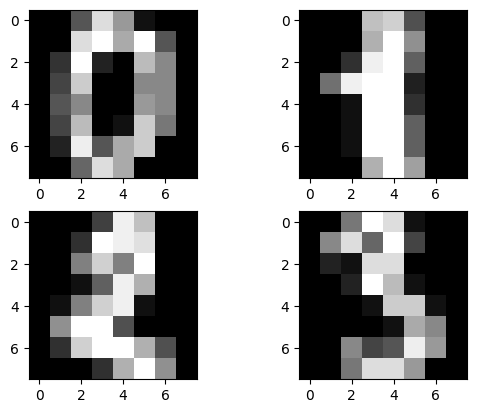

In [3]:
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(digits.images[i],cmap='gray')
plt.show()

##### Exploration des données

In [4]:
print(f"Colonnes du dataset : {digits.keys()}")
print(f"Targets possibles   : {digits.target_names}")
print(f"Première image :\n{digits.images[0]}")
print(f"Nombre total d'images : {digits.images.shape[0]}")

unique, counts = np.unique(digits.target, return_counts=True)
print("Nombre d'occurrences pour chaque chiffre :")
for val, count in zip(unique, counts):
    print(f"{val} : {count} images")

Colonnes du dataset : dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Targets possibles   : [0 1 2 3 4 5 6 7 8 9]
Première image :
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Nombre total d'images : 1797
Nombre d'occurrences pour chaque chiffre :
0 : 178 images
1 : 182 images
2 : 177 images
3 : 183 images
4 : 181 images
5 : 182 images
6 : 181 images
7 : 179 images
8 : 174 images
9 : 180 images


##### On crée notre feature matrix et notre vecteur de labels

In [5]:
X = digits.data
y = digits.target

print(f"Feature matrix shape: {X.shape}. Max value = {np.max(X)}, Min value = {np.min(X)}, Mean value = {np.mean(X)}")
print(f"Labels shape: {y.shape}")

Feature matrix shape: (1797, 64). Max value = 16.0, Min value = 0.0, Mean value = 4.884164579855314
Labels shape: (1797,)


Le "label" valeur exacte dans l'échantillon et la "taget" est la valeur à predire

##### On normalise nos valeurs

In [6]:
F = X/16

print(f"Feature matrix F shape: {F.shape}. Max value = {np.max(F)}, Min value = {np.min(F)}, Mean value = {np.mean(F)}")

Feature matrix F shape: (1797, 64). Max value = 1.0, Min value = 0.0, Mean value = 0.30526028624095713


##### On réduit la dimensions des datas

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
F_pca = pca.fit_transform(F) 

On plot en 2D le résultat

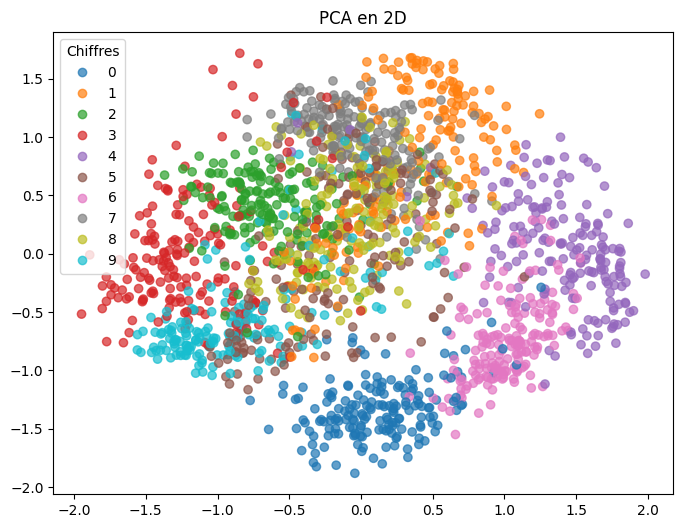

In [8]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(F_pca[:, 0], F_pca[:, 1], c=digits.target, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Chiffres")
plt.title("PCA en 2D")
plt.savefig("../../img/scattle_pca.png")

On remarque que les chiffres sont plutot groupé entre eux, ce qui nous donne une piste pour savoir de quel chiffre il sagit selon sa position sur le graphe.

##### On reconstruit à partir de cette réduction

In [9]:
from sklearn.metrics import mean_squared_error
F_ipca = pca.inverse_transform(F_pca)
print(f"L'erreur quadratique moyenne est :", mean_squared_error(F, F_ipca))

L'erreur quadratique moyenne est : 0.0524258289092244


##### On compare nos deux images

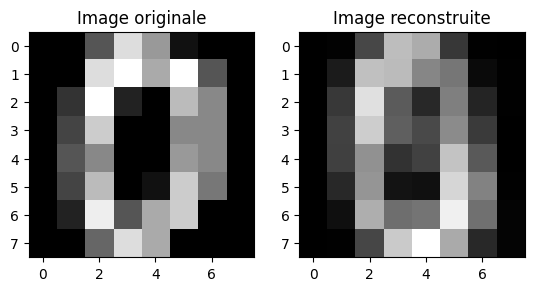

In [10]:
plt.subplot(1,2,1)
img0 = X[0].reshape(8,8)
plt.imshow(img0,cmap='gray')
plt.title("Image originale")

plt.subplot(1,2,2)
img1 = F_ipca[0].reshape(8,8)
plt.imshow(img1,cmap='gray')
plt.title("Image reconstruite")

plt.savefig("../../img/comparaison.png")

##### On va regarder si le nombre de dimension impact la qualité de l'image

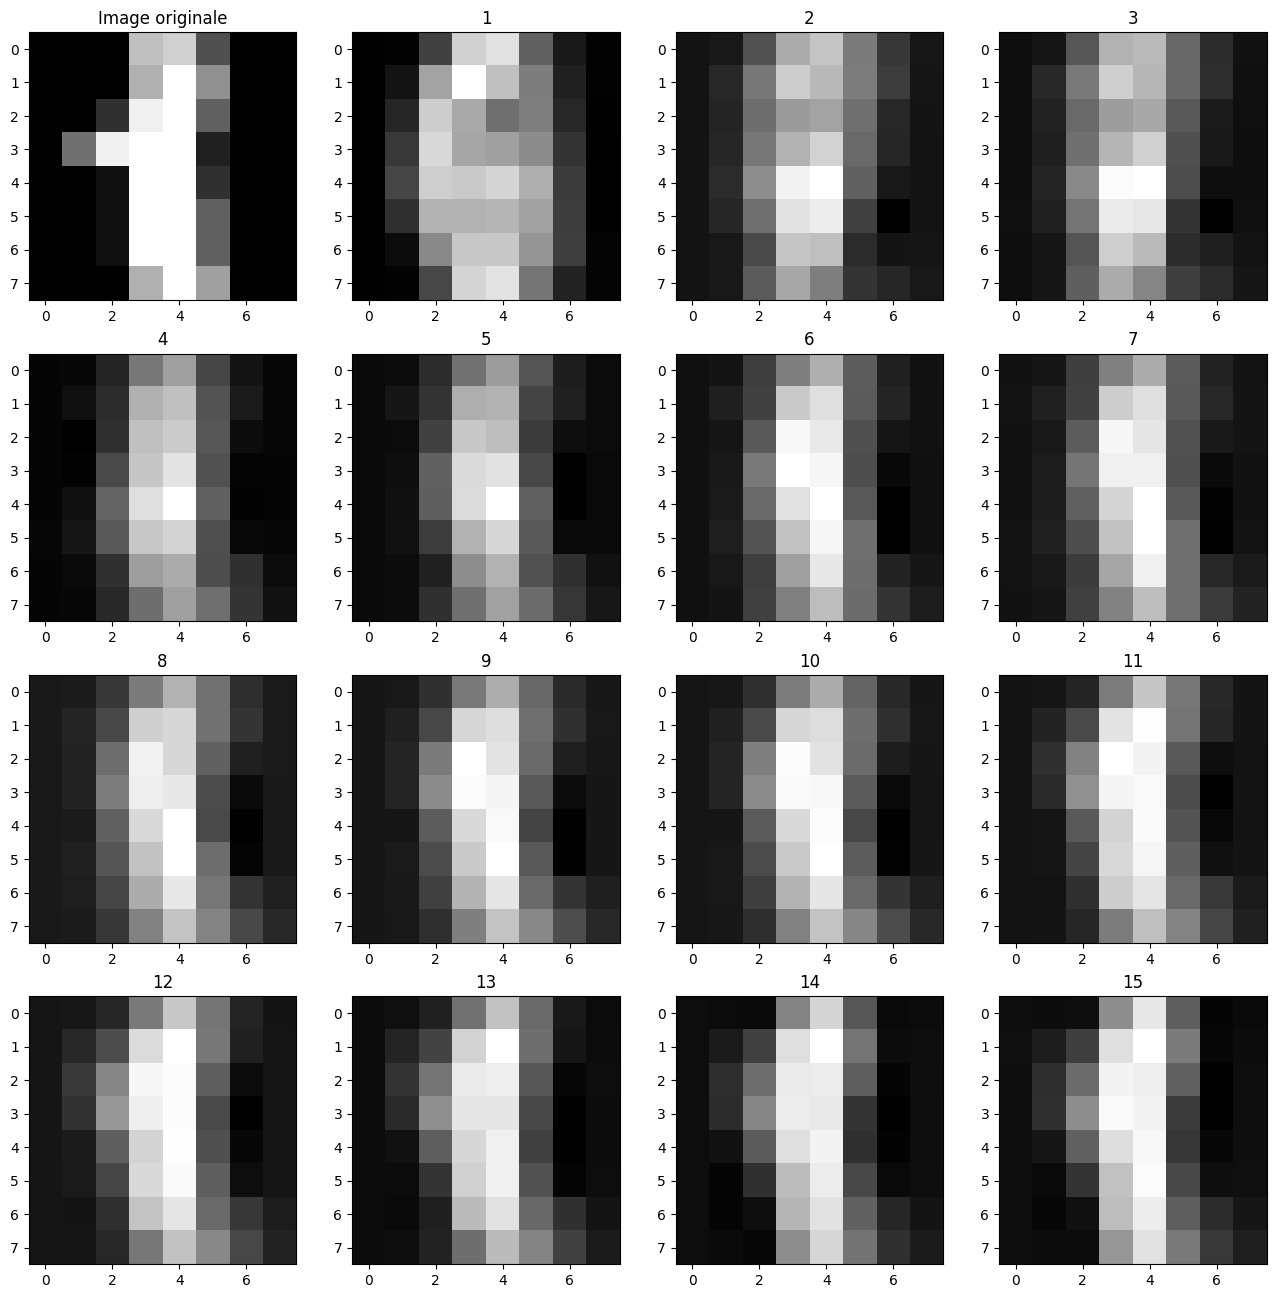

In [11]:
plt.figure(figsize=(16,16))
plt.subplot(4,4,1)
plt.imshow(X[1].reshape(8,8), cmap='gray')
plt.title("Image originale")

for j in range(1,16):
    plt.subplot(4,4,j+1)
    pca = PCA(n_components=j)
    F_pca = pca.fit_transform(F) 
    F_ipca = pca.inverse_transform(F_pca)
    plt.imshow(F_ipca[1].reshape(8,8),cmap='gray')
    plt.title(j)
plt.savefig("../../img/comparison_pca.png")

##### On trace la variance expliqué cumulé 

Nombre minimal de composantes pour 90% de variance : 21


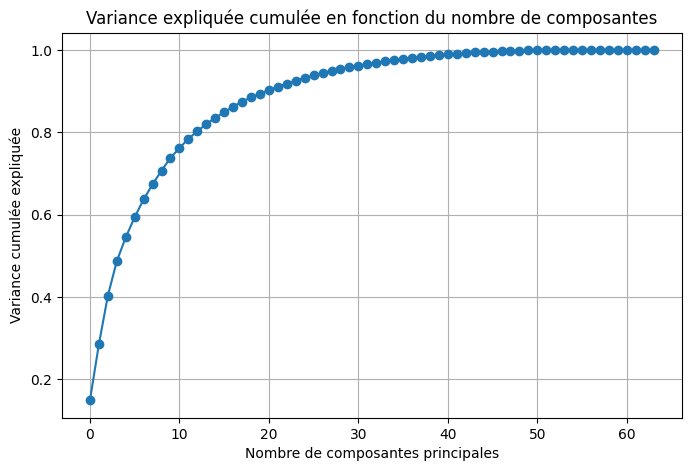

In [12]:
pca = PCA(n_components=X.shape[1])
pca.fit(X)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance cumulée expliquée")
plt.title("Variance expliquée cumulée en fonction du nombre de composantes")
plt.grid(True)
plt.savefig("../../img/cumvar.png")
print(f"Nombre minimal de composantes pour 90% de variance :",np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1 )

L'interet de ce graphique est de déterminer le nombre optimal de composantes à conserver. À partir d'un certain nombre de composantes l'augmentation de la variance n'est pas assez interessante par rapport aux complications générées par l'augmentation du nombre de composantes.

##### Feature engineering partitionnement en fonction des zones

In [13]:
def extract_zone_features(X):
    n = X.shape[0]
    res = np.zeros((n, 3))
    for i in range(n):
        zone1 = np.mean(X[i, 0:24])
        zone2 = np.mean(X[i, 24:40])
        zone3 = np.mean(X[i, 40:64])
        res[i, :] = [zone1, zone2, zone3]
    return res

F_zones = extract_zone_features(X)

print(f"Feature matrix F_zones shape: {F_zones.shape}")

Feature matrix F_zones shape: (1797, 3)


##### Feature pour la detection des bords

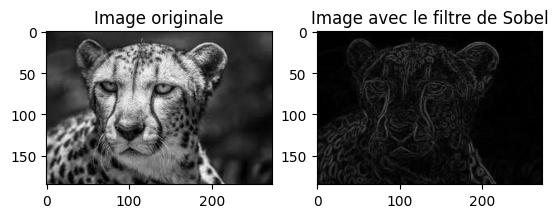

In [14]:
from skimage.filters import sobel
img = plt.imread("../../img/chita.jpg")
img_edges = sobel(img)
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Image originale")
plt.subplot(1,2,2)
plt.imshow(img_edges, cmap='gray')
plt.title("Image avec le filtre de Sobel")
plt.savefig("../../img/chita_edges.png")

Maintenant pour nos data.

In [15]:
def apply_sobel(X):
    n = X.shape[0]
    sobel_mean = np.zeros((n,1))
    for i in range(n):
        img = X[i].reshape(8, 8)
        sobel_img = sobel(img)
        sobel_mean[i] = np.mean(sobel_img)
    return sobel_mean

F_edges = apply_sobel(X)
print(f"Dimensions après traitement :",F_edges.shape)

Dimensions après traitement : (1797, 1)


##### On met toutes les features ensemble

In [16]:
def all_features(X_normalized):
    pca = PCA(n_components=20)
    X_pca = pca.fit_transform(X_normalized)
    X_zone = extract_zone_features(X_normalized)
    X_sobel = apply_sobel(X_normalized)
    X_all = np.hstack((X_pca, X_zone, X_sobel))
    return X_all

print(f"Dimensions avec toutes les features :",all_features(F).shape)

Dimensions avec toutes les features : (1797, 24)


### Division, classification et prétraitement

On se place maintenant dans un contexte plus propice au Machile Learning. 

##### Division des données

On divise les données en s'assurant d'une répartition équilibré entre les chiffres grâce à la fonction _train\_test\_split_

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Taille du X_train :", X_train.shape)
print("Taille du X_test :", X_test.shape)
print("Taille du y_train :", y_train.shape)
print("Taille du y_test :", y_test.shape)

Taille du X_train : (1437, 64)
Taille du X_test : (360, 64)
Taille du y_train : (1437,)
Taille du y_test : (360,)


 Vérifions la distribution


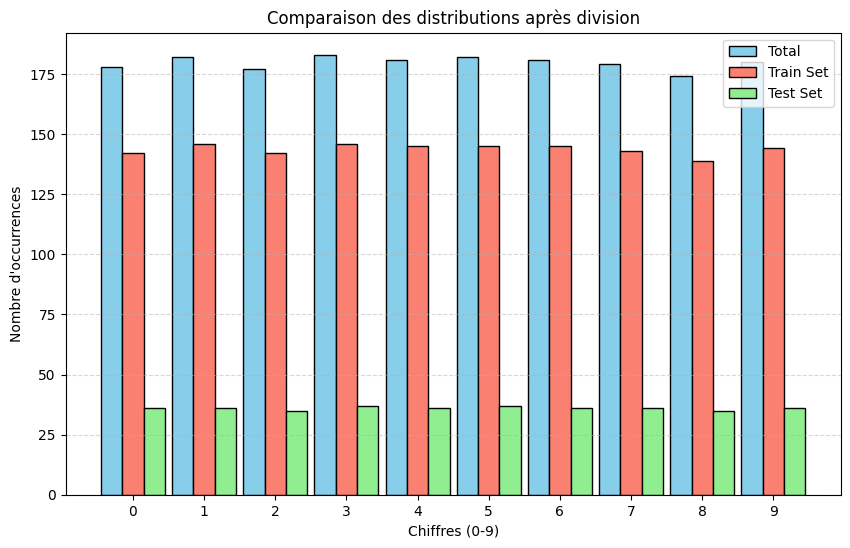

In [18]:
unique, counts_y = np.unique(y, return_counts=True)
_, counts_train = np.unique(y_train, return_counts=True)
_, counts_test = np.unique(y_test, return_counts=True)

bar_width = 0.3
x_positions = np.arange(len(unique))

plt.figure(figsize=(10, 6))
plt.bar(x_positions - bar_width, counts_y, width=bar_width, color='skyblue', edgecolor='black', label="Total")
plt.bar(x_positions, counts_train, width=bar_width, color='salmon', edgecolor='black', label="Train Set")
plt.bar(x_positions + bar_width, counts_test, width=bar_width, color='lightgreen', edgecolor='black', label="Test Set")

plt.xlabel("Chiffres (0-9)")
plt.ylabel("Nombre d'occurrences")
plt.title("Comparaison des distributions après division")
plt.xticks(x_positions, unique)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig("../../img/comparison_division.png")

##### Création de wrapper

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion

class EdgeInfoPreprocessing(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        n = X.shape[0]
        sobel_mean = np.zeros((n,1))
        for i in range(n):
            img = X[i].reshape(8, 8)
            sobel_img = sobel(img)
            sobel_mean[i] = np.mean(sobel_img)
        return sobel_mean

class ZonalInfoPreprocessing(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        n = X.shape[0]
        res = np.zeros((n, 3))
        for i in range(n):
            zone1 = np.mean(X[i, 0:24])
            zone2 = np.mean(X[i, 24:40])
            zone3 = np.mean(X[i, 40:64])
            res[i, :] = [zone1, zone2, zone3]
        return res

On crée maintenant le transformateur

In [20]:
all_features = FeatureUnion([
    ('pca', PCA(n_components=20)),
    ('zones', ZonalInfoPreprocessing()),
    ('sobel', EdgeInfoPreprocessing())
])

##### Création d'une pipeline avec SVC

In [21]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

clf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('features', all_features),
    ('postscale', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

##### On entraine le modele

In [22]:
clf.fit(X_train, y_train)

predict_test = clf.predict(X_test)
predict_train = clf.predict(X_train)

print("Accuracy of the SVC on the train set: ", sum(y_train==predict_train)/len(y_train))
print("Accuracy of the SVC on the test set: ", sum(y_test==predict_test)/len(y_test))

Accuracy of the SVC on the train set:  0.9993041057759221
Accuracy of the SVC on the test set:  0.9777777777777777


On plot la matrice de confusion

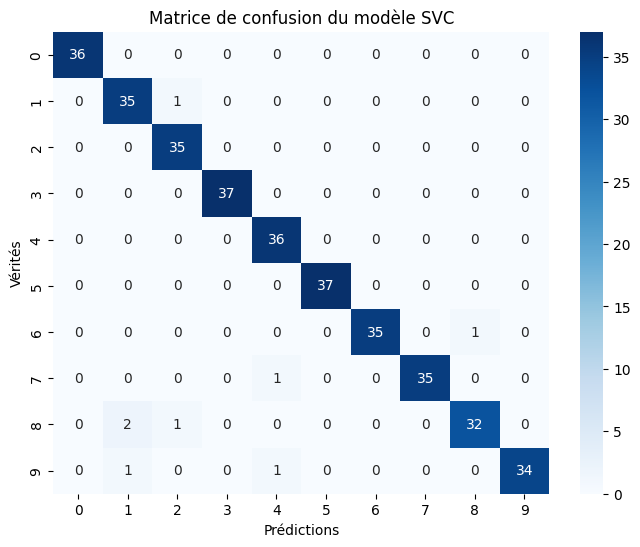

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion du modèle SVC")
plt.savefig("../../img/confusion_matrix_svc.png")

La matrice nous montre le nombre de fois que un nombre est prit pour un nombre entre 0 et 9. Si la diagonale est foncée cela veut dire que les nombres souvent interprétés comme eux même.

### Hyperparameter tuning and CV

On passe a un kernel _rbf_

In [24]:
clf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('features', all_features),
    ('postscale', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('features',
                 FeatureUnion(transformer_list=[('pca', PCA(n_components=20)),
                                                ('zones',
                                                 ZonalInfoPreprocessing()),
                                                ('sobel',
                                                 EdgeInfoPreprocessing())])),
                ('postscale', StandardScaler()), ('svc', SVC())])

Recherche des meilleurs paramètres

In [25]:
param_grid = {
    'features__pca__n_components' : [20, 25, 30],
    'svc__C'  : [0.01, 0.1, 1, 10, 100, 1000],
    'svc__gamma' : [0.01,0.05,0.1,0.25,0.5]
}

from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(clf, param_grid = param_grid)
grid_search.fit(X_train, y_train)

print(" K-Fold Cross-Validation Results:")
print(f"- Best Cross-validation score: {grid_search.best_score_}")
print(f"- Best parameters found: {grid_search.best_estimator_}")


 K-Fold Cross-Validation Results:
- Best Cross-validation score: 0.989559136662795
- Best parameters found: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('features',
                 FeatureUnion(transformer_list=[('pca', PCA(n_components=30)),
                                                ('zones',
                                                 ZonalInfoPreprocessing()),
                                                ('sobel',
                                                 EdgeInfoPreprocessing())])),
                ('postscale', StandardScaler()),
                ('svc', SVC(C=1, gamma=0.05))])


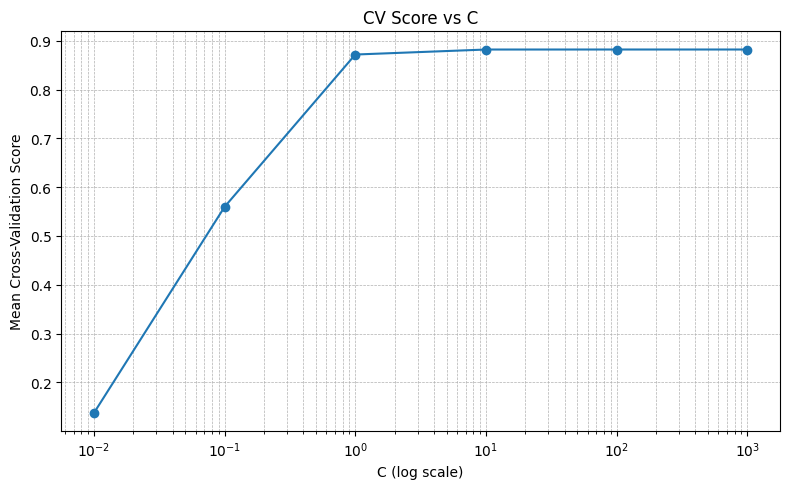

In [27]:
import pandas as pd

results_df = pd.DataFrame(grid_search.cv_results_)

# Group by 'param_svc__C' and compute the mean test score across different gamma and n_components
mean_scores_by_C = results_df.groupby('param_svc__C')['mean_test_score'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(mean_scores_by_C.index, mean_scores_by_C.values, marker='o')
plt.xscale('log')  # <- This sets the x-axis to log scale
plt.xlabel('C (log scale)')
plt.ylabel('Mean Cross-Validation Score')
plt.title('CV Score vs C')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("../../img/CV_score.png")

On trouve n_components = 30, C = 10, gamma=0.05.
On a un score de 0.989559136662795.